## 1. Environment Setup

**What this does:** Installs PySpark inside the Colab runtime. PySpark is not pre-installed by default, so this step has to run first, before anything else that imports `pyspark`.

**Why PySpark instead of plain pandas:** The dataset covers a full year of trips (tens of millions of rows). Loading and grouping data at that scale with pandas alone would be slow and memory-intensive. PySpark distributes the work across available CPU cores and only brings small, aggregated results back into pandas for plotting.

In [13]:
!pip install pyspark -q
print("PySpark installed")

PySpark installed


### 1.1 Import Required Libraries

- `SparkSession` / `functions as F` — core PySpark objects used to build the Spark session and to write column expressions (grouping, aggregating, conditional logic) against the DataFrame.
- `pandas` — used for the small, already-aggregated tables that come back from Spark (via `.toPandas()`), which are what actually get plotted.
- `matplotlib.pyplot` / `seaborn` — used for all charts (bar charts, heatmaps, histograms) in the analysis.
- `warnings.filterwarnings('ignore')` — suppresses non-critical warning noise so the output stays readable.

In [14]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("All imports done")

All imports done


## 2. Mount Google Drive

**What this does:** Mounts the user's Google Drive inside the Colab VM so the cleaned parquet dataset (stored on Drive) can be read directly by Spark in a later step, without needing to re-upload or re-download the data each session.

In [15]:
from google.colab import drive
drive.mount('/content/drive')
print("Drive mounted")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted


## 3. Initialize Spark Session

**What this does:** Creates a local Spark session that will run using all available cores on the Colab machine (`master("local[*]")`).

**Key configs:**
- `spark.driver.memory = 4g` — gives the Spark driver enough memory headroom for the aggregations and `.toPandas()` conversions used later, given the size of the full-year dataset.
- `spark.sql.shuffle.partitions = 8` — reduces the default shuffle partition count (Spark's default of 200 is tuned for large clusters, not a single Colab VM), avoiding unnecessary overhead on a small local setup.
- `setLogLevel("WARN")` — keeps Spark's internal logging quiet so it doesn't clutter the notebook output.

In [16]:
spark = (
    SparkSession.builder
    .appName("nyc-taxi-demand-pricing")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")
print("Spark version:", spark.version)
print("Session ready")

Spark version: 4.0.3
Session ready


## 4. Load the Cleaned Dataset

**What this does:** Points Spark at the pre-cleaned, all-months parquet dataset on Google Drive and loads it as a Spark DataFrame (`df`). `df.count()` and `df.printSchema()` report the total row/column counts and schema, a quick sanity check that the data loaded correctly and that expected engineered columns (e.g. `pickup_month`, `pickup_hour`, `is_weekend`, `tip_pct`, `fare_per_mile`, `ratecode_label`, `cbd_congestion_fee`, `trip_duration_minutes`) are present.

Note that `df` is a **Spark DataFrame**, not a pandas DataFrame — the row-level data stays distributed and is never fully loaded into local memory. Every task below follows the same pattern: aggregate at the Spark level first, then call `.toPandas()` only on the small, already-summarized result.

In [17]:
DRIVE_PATH = "/content/drive/.shortcut-targets-by-id/1AG7n5J82rGTCKZTIhAWnWDJ0Ia16Ugcb/all_months_cleaned"

df = spark.read.parquet(DRIVE_PATH)

print(f"Total rows: {df.count():,}")
print(f"Total columns: {len(df.columns)}")
df.printSchema()

Total rows: 43,790,431
Total columns: 35
root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp (nullable = true)
 |-- tpep_dropoff_datetime: timestamp (nullable = true)
 |-- passenger_count: integer (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: integer (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: integer (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)
 |-- cbd_congestion_fee: double (nullable = true)
 |-- trip_duration_minutes: double

## 5. Task 1 — Monthly Trip Volume & Revenue (Seasonality)

**Business question:** How does taxi demand and revenue change month to month across the year, and are there identifiable seasonal peaks or troughs?

**What this does:** Groups all trips by `pickup_month`, counts trips, sums `total_amount` for total revenue, and averages `fare_amount`. The result is converted to pandas and plotted as two stacked bar charts — trip volume (in millions) on top and revenue (in $ millions) below — with value labels on each bar. Saved to `monthly_seasonality.png`.

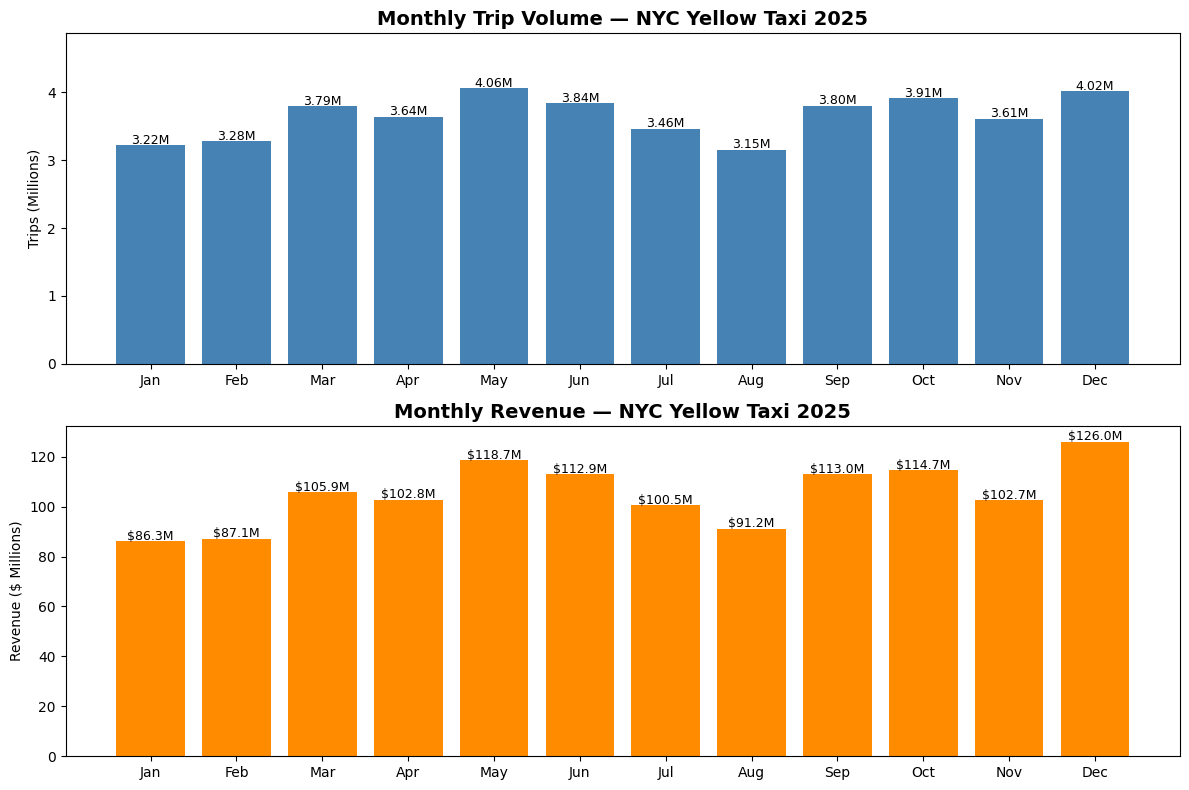

Task 1 done


In [18]:
# Monthly trip volume & revenue
monthly = (
    df.groupBy("pickup_month")
    .agg(
        F.count("*").alias("total_trips"),
        F.round(F.sum("total_amount"), 2).alias("total_revenue"),
        F.round(F.avg("fare_amount"), 2).alias("avg_fare")
    )
    .orderBy("pickup_month")
    .toPandas()
)

month_names = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]
monthly["month_name"] = monthly["pickup_month"].apply(lambda x: month_names[x-1])

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Trip volume
axes[0].bar(monthly["month_name"], monthly["total_trips"]/1_000_000, color="steelblue")
axes[0].set_title("Monthly Trip Volume — NYC Yellow Taxi 2025", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Trips (Millions)")
axes[0].set_ylim(0, monthly["total_trips"].max()/1_000_000 * 1.2)
for i, v in enumerate(monthly["total_trips"]):
    axes[0].text(i, v/1_000_000 + 0.02, f"{v/1_000_000:.2f}M", ha="center", fontsize=9)

# Revenue
axes[1].bar(monthly["month_name"], monthly["total_revenue"]/1_000_000, color="darkorange")
axes[1].set_title("Monthly Revenue — NYC Yellow Taxi 2025", fontsize=14, fontweight="bold")
axes[1].set_ylabel("Revenue ($ Millions)")
for i, v in enumerate(monthly["total_revenue"]):
    axes[1].text(i, v/1_000_000 + 0.5, f"${v/1_000_000:.1f}M", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("monthly_seasonality.png", dpi=150, bbox_inches="tight")
plt.show()
print("Task 1 done")

**Business interpretation:** Comparing the two bar charts shows whether revenue growth simply tracks trip volume, or whether some months generate disproportionately more revenue per trip (longer trips, more airport runs, etc.). Months that stand out as unusually high or low are worth flagging for fleet operators — signaling when to add supply or expect a lull in earnings.

## 6. Task 2 — Hourly Demand Heatmap (Weekday vs. Weekend)

**Business question:** At what hours of the day is demand highest, and does that pattern differ between weekdays and weekends?

**What this does:** Groups trips by `pickup_hour` and `is_weekend`, counts trips per combination, then pivots the result into a 2-row (Weekday / Weekend) × 24-column (hour 0–23) table, rendered as a heatmap (trip counts in thousands). Saved to `hourly_demand_heatmap.png`.

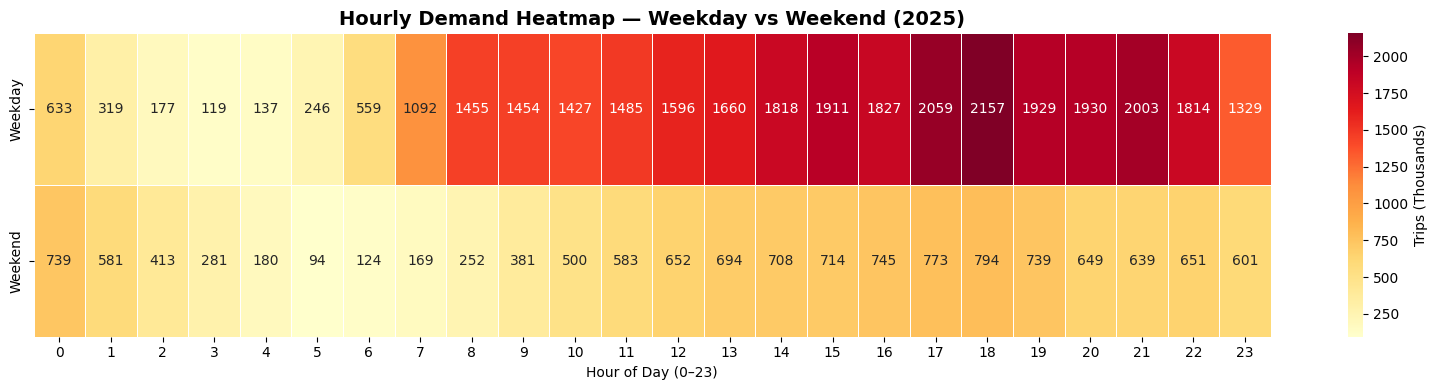

=== TASK 2 FINDINGS ===
Peak demand      : Hour 18 — Weekday (2157K trips)
Lowest demand    : Hour 5 — Weekend (94K trips)


In [19]:
# Hourly demand heatmap
hourly = (
    df.groupBy("pickup_hour", "is_weekend")
    .agg(F.count("*").alias("trips"))
    .toPandas()
)

hourly["day_type"] = hourly["is_weekend"].apply(lambda x: "Weekend" if x else "Weekday")

pivot = hourly.pivot_table(index="day_type", columns="pickup_hour", values="trips")

fig, ax = plt.subplots(figsize=(16, 4))
sns.heatmap(
    pivot/1000,
    annot=True, fmt=".0f",
    cmap="YlOrRd",
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "Trips (Thousands)"}
)
ax.set_title("Hourly Demand Heatmap — Weekday vs Weekend (2025)", fontsize=14, fontweight="bold")
ax.set_xlabel("Hour of Day (0–23)")
ax.set_ylabel("")

plt.tight_layout()
plt.savefig("hourly_demand_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

print("=== TASK 2 FINDINGS ===")
peak = hourly.loc[hourly['trips'].idxmax()]
low = hourly.loc[hourly['trips'].idxmin()]
print(f"Peak demand      : Hour {int(peak['pickup_hour'])} — {peak['day_type']} ({peak['trips']/1000:.0f}K trips)")
print(f"Lowest demand    : Hour {int(low['pickup_hour'])} — {low['day_type']} ({low['trips']/1000:.0f}K trips)")

**Business interpretation:** The heatmap is the fastest way to see whether weekday demand is driven by commute-style peaks (morning and evening rush) versus a flatter, later-starting weekend pattern. This directly informs driver shift planning and dynamic dispatch.

## 7. Task 3 — Fare Distribution & Airport vs. Standard Trip Economics

**Business question:** How much more (if at all) do airport trips (JFK, Newark) earn compared to standard-rate trips, and how does the fare distribution shape differ?

**What this does:** Two Spark aggregations: (1) `fare_data` computes trip count, average fare, distance, tip %, fare-per-mile, and duration for each `ratecode_label` in {Standard, JFK, Newark}. (2) `fare_sample` takes a lightweight 1% random sample (capped at fares ≤ $150 to exclude extreme outliers) so a histogram of fare distribution can be drawn without loading the full dataset. Results are plotted as an overlapping histogram plus a bar chart of average fare by category. Saved to `fare_distribution.png`.

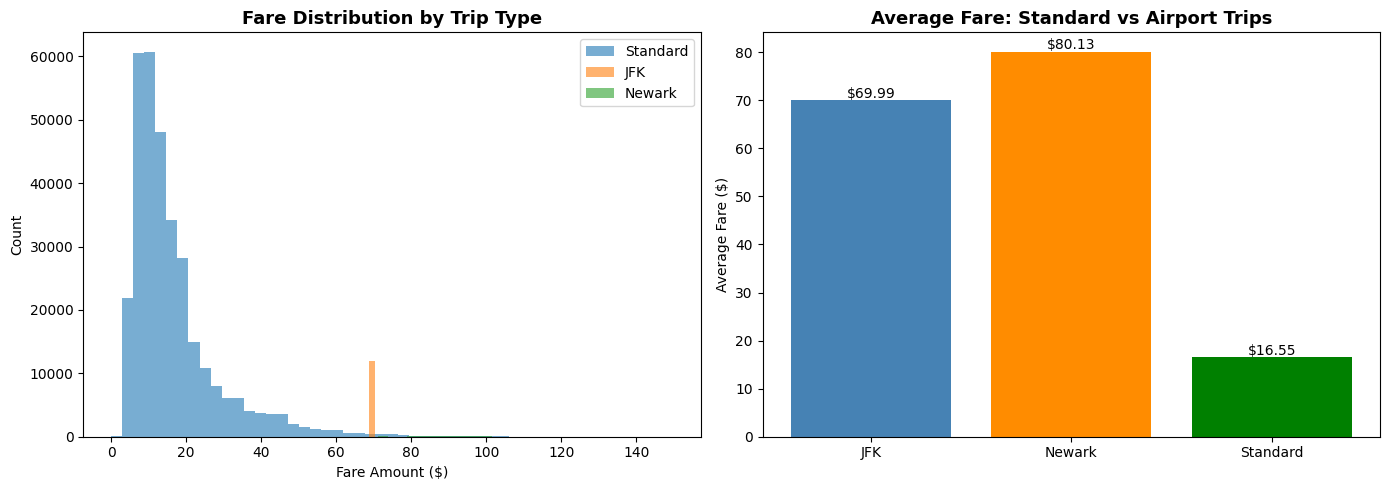


Trip Economics Summary:
ratecode_label    trips  avg_fare  avg_distance  avg_tip_pct  avg_fare_per_mile  avg_duration_min
           JFK  1188806     69.99         17.95        17.12               8.11             53.66
        Newark   121786     80.13         14.47        14.54              10.81             37.57
      Standard 32526616     16.55          2.64        22.41               8.48             15.11
Task 3 done


In [21]:
# Fare distribution & airport vs standard trip economics
fare_data = (
    df.filter(F.col("ratecode_label").isin(["Standard", "JFK", "Newark"]))
    .groupBy("ratecode_label")
    .agg(
        F.count("*").alias("trips"),
        F.round(F.avg("fare_amount"), 2).alias("avg_fare"),
        F.round(F.avg("trip_distance"), 2).alias("avg_distance"),
        F.round(F.avg("tip_pct"), 2).alias("avg_tip_pct"),
        F.round(F.avg("fare_per_mile"), 2).alias("avg_fare_per_mile"),
        F.round(F.avg("trip_duration_minutes"), 2).alias("avg_duration_min")
    )
    .toPandas()
)

# Fare distribution sample
fare_sample = (
    df.filter(
        (F.col("ratecode_label").isin(["Standard", "JFK", "Newark"])) &
        (F.col("fare_amount") <= 150)
    )
    .select("fare_amount", "ratecode_label")
    .sample(fraction=0.01)
    .toPandas()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fare distribution by rate type
for label in ["Standard", "JFK", "Newark"]:
    subset = fare_sample[fare_sample["ratecode_label"] == label]
    axes[0].hist(subset["fare_amount"], bins=50, alpha=0.6, label=label)
axes[0].set_title("Fare Distribution by Trip Type", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Fare Amount ($)")
axes[0].set_ylabel("Count")
axes[0].legend()

# Avg fare comparison
axes[1].bar(fare_data["ratecode_label"], fare_data["avg_fare"], color=["steelblue","darkorange","green"])
axes[1].set_title("Average Fare: Standard vs Airport Trips", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Average Fare ($)")
for i, v in enumerate(fare_data["avg_fare"]):
    axes[1].text(i, v + 0.5, f"${v}", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("fare_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nTrip Economics Summary:")
print(fare_data.to_string(index=False))
print("Task 3 done")

**Business interpretation:** If airport trips show a materially higher average fare, fare-per-mile, and/or duration, that confirms them as a premium segment worth prioritizing — both for drivers positioning themselves and for fleet operators considering dedicated airport-run incentives. The histogram shape shows whether this is a consistently higher-value segment or driven by a few very large fares.

## 8. Task 4 — Tip Rate Analysis by Hour

**Business question:** Do late-night trips earn drivers a higher tip percentage than the rest of the day?

**What this does:** Filters to `payment_type == 1` (credit card only, since cash tips aren't reliably captured), then groups by `pickup_hour` to compute average tip percentage (`tip_pct`) and average tip amount. Plots two bar charts — tip % and tip $ by hour — with late-night hours (midnight–4 AM) highlighted and a red dashed line marking the overall average. Saved to `tip_rate_analysis.png`; also prints a direct late-night vs. overall comparison.

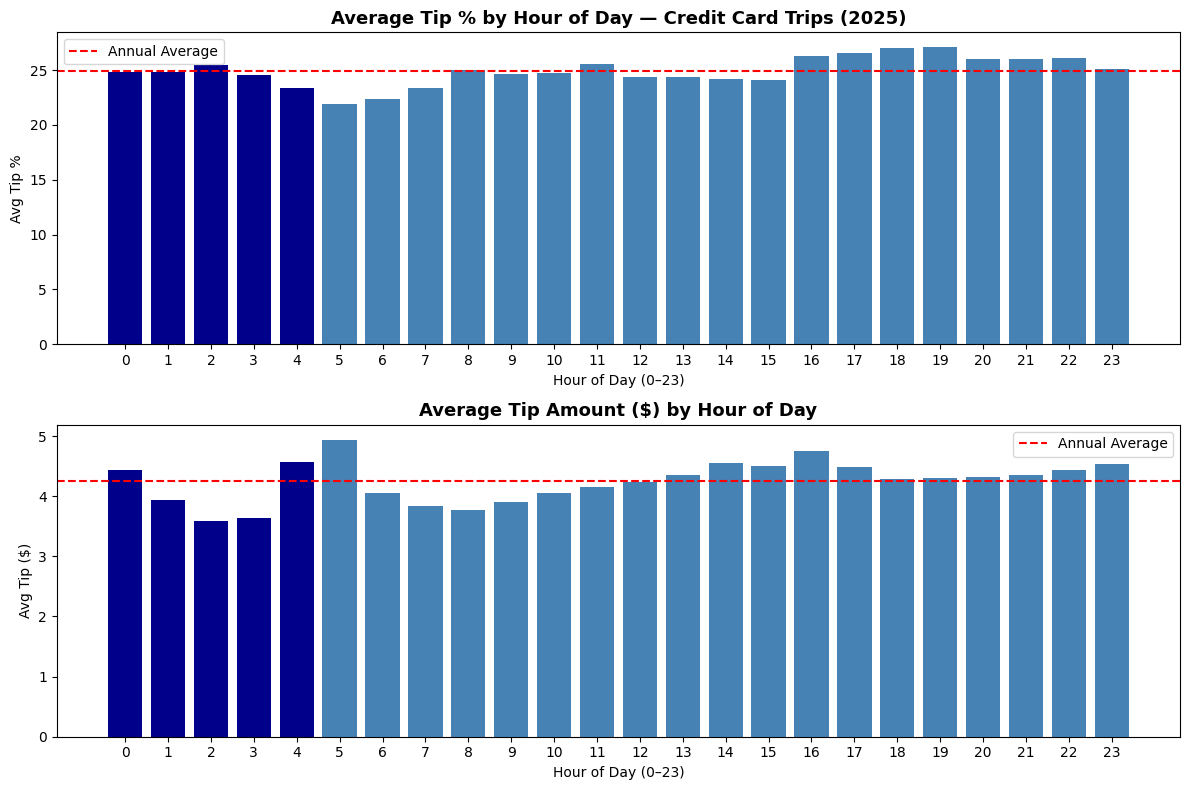


Late Night (12AM-4AM) vs Overall:
  Late night avg tip %  : 24.62%
  Overall avg tip %     : 24.91%
Task 4 done


In [8]:
# Tip rate analysis by hour
tip_hourly = (
    df.filter(F.col("payment_type") == 1)  # credit card only — cash tips not recorded
    .groupBy("pickup_hour")
    .agg(
        F.round(F.avg("tip_pct"), 2).alias("avg_tip_pct"),
        F.round(F.avg("tip_amount"), 2).alias("avg_tip_amount"),
        F.count("*").alias("trips")
    )
    .orderBy("pickup_hour")
    .toPandas()
)

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Avg tip % by hour
colors = ["darkblue" if h in [0,1,2,3,4] else "steelblue" for h in tip_hourly["pickup_hour"]]
axes[0].bar(tip_hourly["pickup_hour"], tip_hourly["avg_tip_pct"], color=colors)
axes[0].set_title("Average Tip % by Hour of Day — Credit Card Trips (2025)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Hour of Day (0–23)")
axes[0].set_ylabel("Avg Tip %")
axes[0].axhline(y=tip_hourly["avg_tip_pct"].mean(), color="red", linestyle="--", label="Annual Average")
axes[0].legend()
axes[0].set_xticks(range(24))

# Avg tip amount by hour
axes[1].bar(tip_hourly["pickup_hour"], tip_hourly["avg_tip_amount"], color=colors)
axes[1].set_title("Average Tip Amount ($) by Hour of Day", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Hour of Day (0–23)")
axes[1].set_ylabel("Avg Tip ($)")
axes[1].axhline(y=tip_hourly["avg_tip_amount"].mean(), color="red", linestyle="--", label="Annual Average")
axes[1].legend()
axes[1].set_xticks(range(24))

plt.tight_layout()
plt.savefig("tip_rate_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nLate Night (12AM-4AM) vs Overall:")
late_night = tip_hourly[tip_hourly["pickup_hour"].isin([0,1,2,3,4])]
print(f"  Late night avg tip %  : {late_night['avg_tip_pct'].mean():.2f}%")
print(f"  Overall avg tip %     : {tip_hourly['avg_tip_pct'].mean():.2f}%")
print("Task 4 done")

**Business interpretation:** If the late-night average tip % sits noticeably above the reference line, that supports encouraging drivers to consider late-night shifts for better tip economics, even though total trip volume is lower at those hours (see Task 2's heatmap).

## 9. Task 5 — CBD Congestion Fee Impact

**Business question:** How does the CBD Congestion Fee affect trip cost and characteristics, and at what times is it most commonly charged?

**What this does:** Two aggregations: (1) `cbd` splits trips into "With CBD Fee" vs. "No CBD Fee" and compares average fare, distance, tip %, total amount, passenger count, and duration. (2) `cbd_hourly` computes, per `pickup_hour`, the percentage of trips carrying the fee. Plotted as a bar chart of "% of trips with CBD fee" by hour and a comparison of average total amount with vs. without the fee. Saved to `cbd_fee_impact.png`.

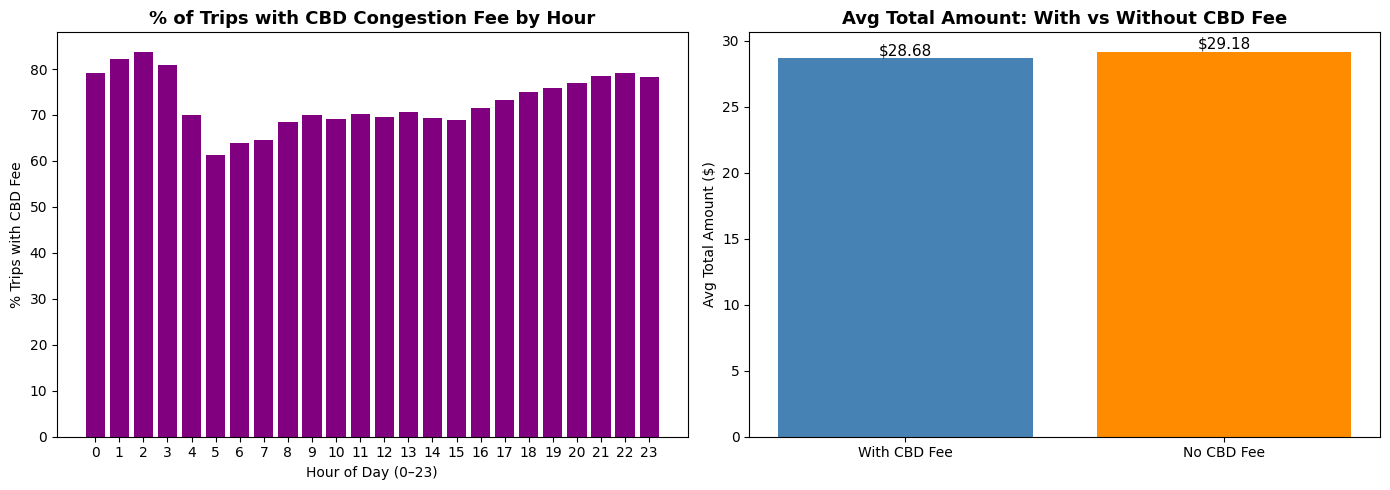


CBD Fee Behavioral Summary:
 has_cbd_fee    trips  avg_fare  avg_distance  avg_tip_pct  avg_total  avg_passengers  avg_duration
With CBD Fee 32020248     19.35          3.18        18.51      28.68            1.26         17.41
  No CBD Fee 11770183     21.73          4.38        15.81      29.18            1.20         18.39
Task 5 done


In [9]:
# CBD Congestion Fee impact
cbd = (
    df.withColumn("has_cbd_fee", F.when(F.col("cbd_congestion_fee") > 0, "With CBD Fee").otherwise("No CBD Fee"))
    .groupBy("has_cbd_fee")
    .agg(
        F.count("*").alias("trips"),
        F.round(F.avg("fare_amount"), 2).alias("avg_fare"),
        F.round(F.avg("trip_distance"), 2).alias("avg_distance"),
        F.round(F.avg("tip_pct"), 2).alias("avg_tip_pct"),
        F.round(F.avg("total_amount"), 2).alias("avg_total"),
        F.round(F.avg("passenger_count"), 2).alias("avg_passengers"),
        F.round(F.avg("trip_duration_minutes"), 2).alias("avg_duration")
    )
    .toPandas()
)

# CBD fee by hour
cbd_hourly = (
    df.withColumn("has_cbd_fee", F.when(F.col("cbd_congestion_fee") > 0, 1).otherwise(0))
    .groupBy("pickup_hour")
    .agg(
        F.round(F.avg("has_cbd_fee") * 100, 2).alias("pct_with_cbd_fee"),
        F.count("*").alias("trips")
    )
    .orderBy("pickup_hour")
    .toPandas()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CBD fee % by hour
axes[0].bar(cbd_hourly["pickup_hour"], cbd_hourly["pct_with_cbd_fee"], color="purple")
axes[0].set_title("% of Trips with CBD Congestion Fee by Hour", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Hour of Day (0–23)")
axes[0].set_ylabel("% Trips with CBD Fee")
axes[0].set_xticks(range(24))

# Avg total amount comparison
axes[1].bar(cbd["has_cbd_fee"], cbd["avg_total"], color=["steelblue", "darkorange"])
axes[1].set_title("Avg Total Amount: With vs Without CBD Fee", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Avg Total Amount ($)")
for i, v in enumerate(cbd["avg_total"]):
    axes[1].text(i, v + 0.2, f"${v}", ha="center", fontsize=11)

plt.tight_layout()
plt.savefig("cbd_fee_impact.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nCBD Fee Behavioral Summary:")
print(cbd.to_string(index=False))
print("Task 5 done")

**Business interpretation:** The hourly chart shows whether CBD-fee trips cluster around commuting hours or spread evenly through the day. The average-total comparison quantifies the fee's real dollar impact on the passenger's bill — useful for pricing communication and for assessing the fee's effect on ridership.

## 10. Task 6 — Driver Revenue Optimization (Best Shifts)

**Business question:** Which shift window (Morning / Afternoon / Night) and day type (Weekday / Weekend) combination is most lucrative for a driver?

**What this does:** Buckets trips into Morning (6 AM–2 PM), Afternoon (2 PM–10 PM), or Night (10 PM–6 AM) based on `pickup_hour`, then groups by `shift` and `is_weekend` to compute trip count, average total amount, average tip %, and average duration for each of the six combinations. Plots two horizontal bar charts — revenue per trip and tip % by shift — with weekend shifts colored differently. Saved to `driver_revenue_optimization.png`, with a ranked table printed.

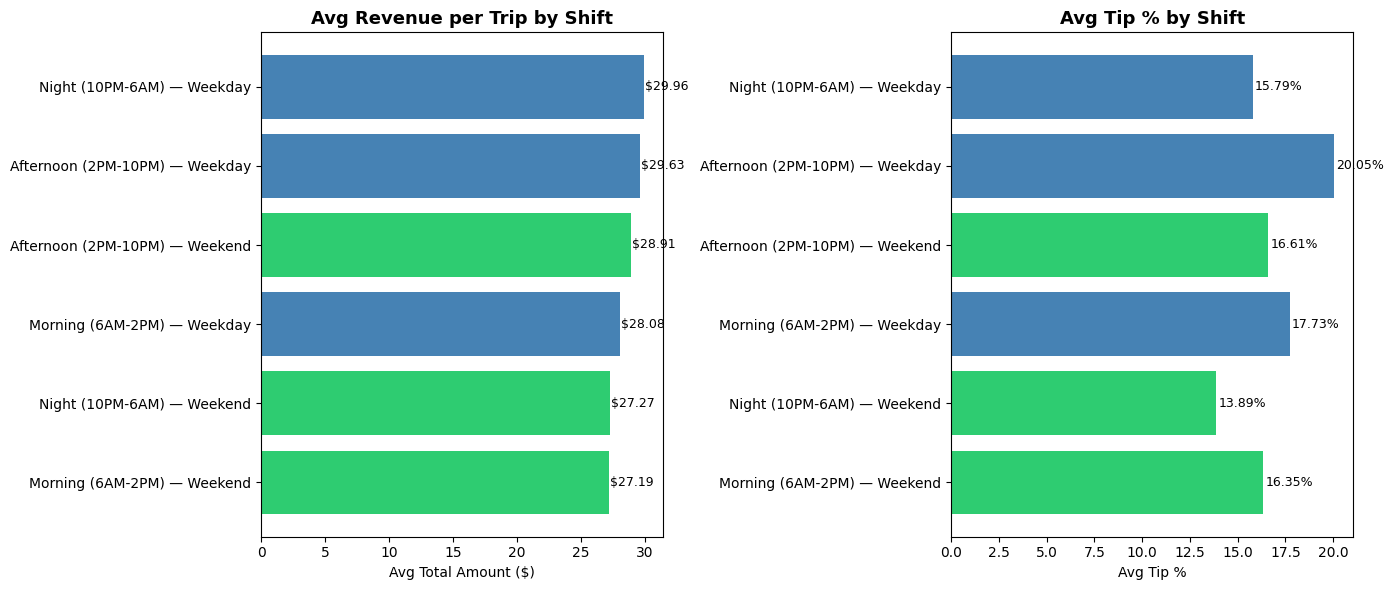


Best Shifts for Drivers:
                     shift_day  avg_total  avg_tip_pct  avg_duration
    Night (10PM-6AM) — Weekday      29.96        15.79         15.88
Afternoon (2PM-10PM) — Weekday      29.63        20.05         18.25
Afternoon (2PM-10PM) — Weekend      28.91        16.61         18.00
   Morning (6AM-2PM) — Weekday      28.08        17.73         18.90
    Night (10PM-6AM) — Weekend      27.27        13.89         15.14
   Morning (6AM-2PM) — Weekend      27.19        16.35         15.70
Task 6 done


In [10]:
# Driver revenue optimization — best shifts
shifts = (
    df.withColumn("shift",
        F.when(F.col("pickup_hour").between(6, 13), "Morning (6AM-2PM)")
         .when(F.col("pickup_hour").between(14, 21), "Afternoon (2PM-10PM)")
         .otherwise("Night (10PM-6AM)")
    )
    .groupBy("shift", "is_weekend")
    .agg(
        F.count("*").alias("trips"),
        F.round(F.avg("total_amount"), 2).alias("avg_total"),
        F.round(F.avg("tip_pct"), 2).alias("avg_tip_pct"),
        F.round(F.avg("trip_duration_minutes"), 2).alias("avg_duration"),
        F.round(F.avg("trips_per_hour"), 2) if "trips_per_hour" in df.columns
            else F.round(F.avg("total_amount") / F.avg("trip_duration_minutes") * 60, 2).alias("revenue_per_hour")
    )
    .toPandas()
)

shifts["day_type"] = shifts["is_weekend"].apply(lambda x: "Weekend" if x else "Weekday")
shifts["shift_day"] = shifts["shift"] + " — " + shifts["day_type"]
shifts = shifts.sort_values("avg_total", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Avg total per trip by shift
colors = ["#2ecc71" if "Weekend" in s else "steelblue" for s in shifts["shift_day"]]
axes[0].barh(shifts["shift_day"], shifts["avg_total"], color=colors)
axes[0].set_title("Avg Revenue per Trip by Shift", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Avg Total Amount ($)")
for i, v in enumerate(shifts["avg_total"]):
    axes[0].text(v + 0.1, i, f"${v}", va="center", fontsize=9)

# Avg tip % by shift
axes[1].barh(shifts["shift_day"], shifts["avg_tip_pct"], color=colors)
axes[1].set_title("Avg Tip % by Shift", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Avg Tip %")
for i, v in enumerate(shifts["avg_tip_pct"]):
    axes[1].text(v + 0.1, i, f"{v}%", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("driver_revenue_optimization.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nBest Shifts for Drivers:")
print(shifts[["shift_day", "avg_total", "avg_tip_pct", "avg_duration"]].sort_values("avg_total", ascending=False).to_string(index=False))
print("Task 6 done")

**Business interpretation:** The ranked table is the most directly actionable output in the notebook — it tells a driver exactly which shift/day-type combination has historically paid the most and tipped the best. Fleet operators can use the same breakdown to decide which combinations most need incentive programs.

## 11. Summary & Wrap-Up

**What this does:** Prints a final confirmation banner listing every chart saved to disk and every task completed, then shuts down the Spark session with `spark.stop()` to free up resources — good practice so a running session doesn't hold memory or slow anything run afterward in the same runtime.

In [22]:
print("=" * 50)
print("PHASE 2 — DEMAND & PRICING ANALYTICS COMPLETE")
print("=" * 50)
print("\nFiles saved:")
print("  ✓ monthly_seasonality.png")
print("  ✓ hourly_demand_heatmap.png")
print("  ✓ fare_distribution.png")
print("  ✓ tip_rate_analysis.png")
print("  ✓ cbd_fee_impact.png")
print("  ✓ driver_revenue_optimization.png")
print("\nTasks completed:")
print("  ✓ Task 1 — Monthly trip volume & revenue seasonality")
print("  ✓ Task 2 — Hourly demand heatmap (weekday vs weekend)")
print("  ✓ Task 3 — Fare distribution & airport vs standard economics")
print("  ✓ Task 4 — Tip rate analysis by hour (late night premium)")
print("  ✓ Task 5 — CBD Congestion Fee behavioral impact")
print("  ✓ Task 6 — Driver revenue optimization model")

spark.stop()
print("\n✓ Spark session closed")

PHASE 2 — DEMAND & PRICING ANALYTICS COMPLETE

Files saved:
  ✓ monthly_seasonality.png
  ✓ hourly_demand_heatmap.png
  ✓ fare_distribution.png
  ✓ tip_rate_analysis.png
  ✓ cbd_fee_impact.png
  ✓ driver_revenue_optimization.png

Tasks completed:
  ✓ Task 1 — Monthly trip volume & revenue seasonality
  ✓ Task 2 — Hourly demand heatmap (weekday vs weekend)
  ✓ Task 3 — Fare distribution & airport vs standard economics
  ✓ Task 4 — Tip rate analysis by hour (late night premium)
  ✓ Task 5 — CBD Congestion Fee behavioral impact
  ✓ Task 6 — Driver revenue optimization model

✓ Spark session closed
